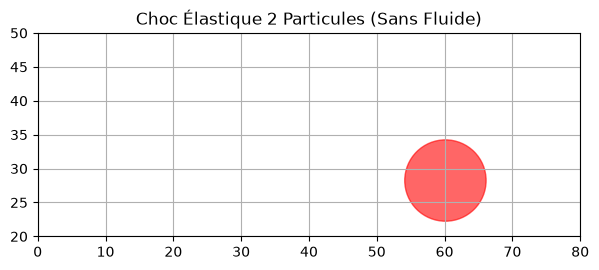

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numba as nb

@nb.jit(nopython=True, fastmath=True)
def resolve_particle_collisions(marker_pos, marker_vel, D_particle1, D_particle2, rho1, rho2):
    """ This function computes the 3D collision response between two spherical particles.
    It works for N  particles : for whatever mass, radius, initial speed.
    It doesn't work when there is more than 1 collision at a time for the same particle.
    """
    m1 = 4/3 * np.pi * (D_particle1 / 2.0) ** 3 * rho1 # mass of particle 1
    m2 = 4/3 * np.pi * (D_particle2 / 2.0) ** 3 * rho2 # mass of particle 2
    R1 = D_particle1 / 2.0 # radius of particle 1
    R2 = D_particle2 / 2.0 # radius of particle 2
    min_dist_sq = (R1 + R2) ** 2
    
    rx = marker_pos[0, 0] - marker_pos[1, 0]
    ry = marker_pos[0, 1] - marker_pos[1, 1]
    rz = marker_pos[0, 2] - marker_pos[1, 2]
    
    vx = marker_vel[0, 0] - marker_vel[1, 0]
    vy = marker_vel[0, 1] - marker_vel[1, 1]
    vz = marker_vel[0, 2] - marker_vel[1, 2]
    
    dist_sq = rx**2 + ry**2 + rz**2
    a = vx**2 + vy**2 + vz**2
    b = 2.0 * (rx*vx + ry*vy + rz*vz)
    c = dist_sq - min_dist_sq

    if c < 0.0:
        raise ValueError("Particles are overlapping at the start of the time step.")
    
    if a > 0.0 and b < 0.0 and (b**2 - 4.0*a*c) >= 0.0:
        delta_t = (-b - np.sqrt(b**2 - 4.0*a*c)) / (2.0 * a)
        
        if 0.0 <= delta_t <= 1.0:
            rx_impact = rx + vx * delta_t
            ry_impact = ry + vy * delta_t
            rz_impact = rz + vz * delta_t
            dist_impact = np.sqrt(rx_impact**2 + ry_impact**2 + rz_impact**2)
            
            if dist_impact > 0.0:
                nx, ny, nz = rx_impact / dist_impact, ry_impact / dist_impact, rz_impact / dist_impact
                v_dot_n = vx * nx + vy * ny + vz * nz
                
                v0_x, v0_y, v0_z = marker_vel[0, 0], marker_vel[0, 1], marker_vel[0, 2]
                v1_x, v1_y, v1_z = marker_vel[1, 0], marker_vel[1, 1], marker_vel[1, 2]
                
                marker_vel[0, 0] -= 2 * m2 / (m1 + m2) * v_dot_n * nx
                marker_vel[0, 1] -= 2 * m2 / (m1 + m2) * v_dot_n * ny
                marker_vel[0, 2] -= 2 * m2 / (m1 + m2) * v_dot_n * nz
                
                marker_vel[1, 0] += 2 * m1 / (m1 + m2) * v_dot_n * nx
                marker_vel[1, 1] += 2 * m1 / (m1 + m2) * v_dot_n * ny
                marker_vel[1, 2] += 2 * m1 / (m1 + m2) * v_dot_n * nz

                marker_pos[0, 0] += v0_x * delta_t + marker_vel[0, 0] * (1.0 - delta_t)
                marker_pos[0, 1] += v0_y * delta_t + marker_vel[0, 1] * (1.0 - delta_t)
                marker_pos[0, 2] += v0_z * delta_t + marker_vel[0, 2] * (1.0 - delta_t)
                
                marker_pos[1, 0] += v1_x * delta_t + marker_vel[1, 0] * (1.0 - delta_t)
                marker_pos[1, 1] += v1_y * delta_t + marker_vel[1, 1] * (1.0 - delta_t)
                marker_pos[1, 2] += v1_z * delta_t + marker_vel[1, 2] * (1.0 - delta_t)
                return

    marker_pos[0, :] += marker_vel[0, :]
    marker_pos[1, :] += marker_vel[1, :]

# Simulation parameters
Nt = 120
D_particle1 = 6.0
R1 = D_particle1 / 2.0
D_particle2 = 12.0
R2 = D_particle2 / 2.0
rho_0 = 1.0
rho1 = 1.14 * rho_0
rho2 = 1.14 * rho_0

marker_pos = np.array([[10.0, 40.0, 35.0], [50.0, 35.0, 35.0]], dtype=np.float64)
marker_vel = np.array([[0.8, 0.0, 0.0], [0.0, 0.0, 0.0]], dtype=np.float64)

# Figure 
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlim(0, 80)
ax.set_ylim(20, 50)
ax.set_aspect('equal')
ax.set_title("Choc Élastique 2 Particules (Sans Fluide)")
ax.grid(True)

c1 = plt.Circle((marker_pos[0, 0], marker_pos[0, 1]), R1, color='blue', fill=True, alpha=0.6)
c2 = plt.Circle((marker_pos[1, 0], marker_pos[1, 1]), R2, color='red', fill=True, alpha=0.6)
ax.add_patch(c1)
ax.add_patch(c2)

def update(frame):
    resolve_particle_collisions(marker_pos, marker_vel, D_particle1, D_particle2, rho1, rho2)
    c1.set_center((marker_pos[0, 0], marker_pos[0, 1]))
    c2.set_center((marker_pos[1, 0], marker_pos[1, 1]))
    return c1, c2

# GIF creation
ani = animation.FuncAnimation(fig, update, frames=Nt, interval=30, blit=True)

# Save GIF
ani.save('collision.gif', writer='pillow', fps=30)

plt.show()

Simulation des chocs analytiques en cours...
Génération du GIF 3D (choc_analytique.gif)...


Frames: 100%|██████████| 50/50 [00:02<00:00, 21.51it/s]


✅ Fichier 'choc_analytique.gif' généré avec succès !


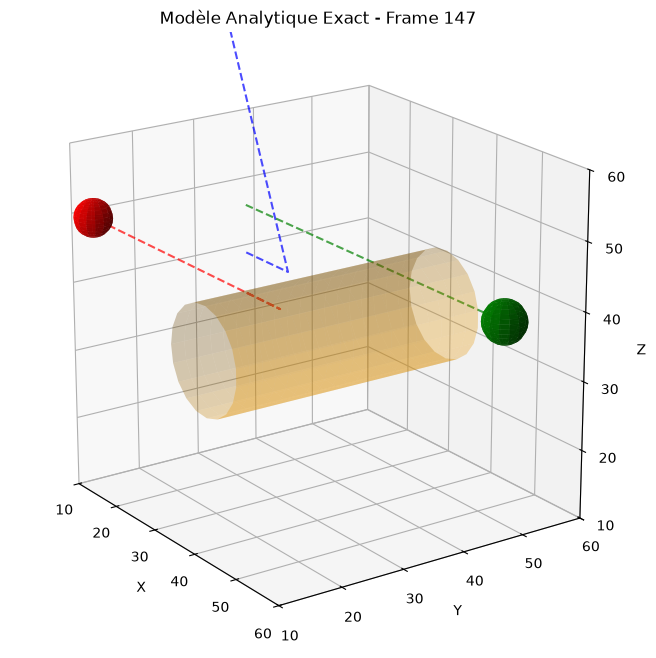

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
import tqdm

def resolve_kinematics_and_collisions(marker_pos, marker_vel, D_particles, cyl_pos, cyl_axis, cyl_radius, cyl_height):
    """
    Met à jour la position et la vitesse avec résolution analytique du choc élastique particule-cylindre.
    """
    N_markers = marker_pos.shape[0]
    N_cyl = cyl_pos.shape[0]
    
    for i in range(N_markers):
        Ri = D_particles[i] / 2.0
        collided = False
        
        for c in range(N_cyl):
            pos_c = cyl_pos[c]
            axis_c = cyl_axis[c] / np.linalg.norm(cyl_axis[c])
            R_cyl = cyl_radius[c]
            H_half = cyl_height[c] / 2.0
            
            # Position et vitesse relatives
            rx, ry, rz = marker_pos[i, 0] - pos_c[0], marker_pos[i, 1] - pos_c[1], marker_pos[i, 2] - pos_c[2]
            vx, vy, vz = marker_vel[i, 0], marker_vel[i, 1], marker_vel[i, 2]
            
            # Projections (axiale et perpendiculaire)
            h_proj = rx * axis_c[0] + ry * axis_c[1] + rz * axis_c[2]
            perp_x, perp_y, perp_z = rx - h_proj * axis_c[0], ry - h_proj * axis_c[1], rz - h_proj * axis_c[2]
            
            vh = vx * axis_c[0] + vy * axis_c[1] + vz * axis_c[2]
            v_perp_x, v_perp_y, v_perp_z = vx - vh * axis_c[0], vy - vh * axis_c[1], vz - vh * axis_c[2]
            
            # Équation d'intersection cylindre-sphère : a*dt^2 + b*dt + c = 0
            a = v_perp_x**2 + v_perp_y**2 + v_perp_z**2
            b = 2.0 * (perp_x * v_perp_x + perp_y * v_perp_y + perp_z * v_perp_z)
            c_eq = (perp_x**2 + perp_y**2 + perp_z**2) - (Ri + R_cyl)**2
            
            # Si on est dans la bande axiale du cylindre
            if abs(h_proj) <= (H_half + Ri):
                if a > 0.0 and b < 0.0 and (b**2 - 4.0 * a * c_eq) >= 0.0:
                    delta_t = (-b - np.sqrt(b**2 - 4.0 * a * c_eq)) / (2.0 * a)
                    
                    # Le choc se produit pendant ce pas de temps
                    if 0.0 <= delta_t <= 1.0:
                        perp_x_imp = perp_x + v_perp_x * delta_t
                        perp_y_imp = perp_y + v_perp_y * delta_t
                        perp_z_imp = perp_z + v_perp_z * delta_t
                        dist_imp = np.sqrt(perp_x_imp**2 + perp_y_imp**2 + perp_z_imp**2)
                        
                        if dist_imp > 0.0:
                            # Calcul de la normale au point d'impact
                            nx, ny, nz = perp_x_imp / dist_imp, perp_y_imp / dist_imp, perp_z_imp / dist_imp
                            v_dot_n = vx * nx + vy * ny + vz * nz
                            v0_i = marker_vel[i].copy()
                            
                            # Choc élastique parfait : inversion de la composante normale
                            marker_vel[i, 0] -= 2.0 * v_dot_n * nx
                            marker_vel[i, 1] -= 2.0 * v_dot_n * ny
                            marker_vel[i, 2] -= 2.0 * v_dot_n * nz
                            
                            # Déplacement exact : translation jusqu'à l'impact + translation post-impact
                            marker_pos[i, 0] += v0_i[0] * delta_t + marker_vel[i, 0] * (1.0 - delta_t)
                            marker_pos[i, 1] += v0_i[1] * delta_t + marker_vel[i, 1] * (1.0 - delta_t)
                            marker_pos[i, 2] += v0_i[2] * delta_t + marker_vel[i, 2] * (1.0 - delta_t)
                            
                            collided = True
                            break
                            
        # S'il n'y a pas eu de choc, on avance normalement
        if not collided:
            marker_pos[i, 0] += marker_vel[i, 0]
            marker_pos[i, 1] += marker_vel[i, 1]
            marker_pos[i, 2] += marker_vel[i, 2]

def run_standalone_simulation():
    # --- Paramètres de la géométrie ---
    cyl_pos = np.array([[35.0, 35.0, 35.0]])
    cyl_axis = np.array([[0.0, 1.0, 0.0]])
    cyl_radius = np.array([8.0])
    cyl_height = np.array([40.0])
    
    D_particles = [6.0, 6.0, 6.0]
    N_markers = len(D_particles)
    Nt = 150
    
    # --- Conditions initiales ---
    marker_pos = np.zeros((N_markers, 3))
    marker_vel = np.zeros((N_markers, 3))
    
    # Particule 0 : Choc frontal (tape plein centre, repart en arrière)
    marker_pos[0] = [15.0, 35.0, 35.0]
    marker_vel[0] = [0.4, 0.0, 0.0]
    
    # Particule 1 : Choc rasant (tape avec un angle, déviée sur le côté)
    marker_pos[1] = [15.0, 35.0, 41.0]
    marker_vel[1] = [0.4, 0.0, 0.0]
    
    # Particule 2 : Passe complètement à côté (aucun choc)
    marker_pos[2] = [15.0, 35.0, 48.0]
    marker_vel[2] = [0.4, 0.0, 0.0]
    
    # Historique
    marker_pos_hist = np.zeros((N_markers, Nt, 3))
    
    print("Simulation des chocs analytiques en cours...")
    for t in range(Nt):
        resolve_kinematics_and_collisions(marker_pos, marker_vel, D_particles, cyl_pos, cyl_axis, cyl_radius, cyl_height)
        for m in range(N_markers):
            marker_pos_hist[m, t] = marker_pos[m]
            
    return marker_pos_hist, D_particles, cyl_pos, cyl_axis, cyl_radius, cyl_height

def generate_3d_gif(marker_pos_hist, D_particles, cyl_pos, cyl_axis, cyl_radius, cyl_height, filename='choc_analytique.gif'):
    print(f"Génération du GIF 3D ({filename})...")
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    frames = []

    Nt = marker_pos_hist.shape[1]
    N_markers = marker_pos_hist.shape[0]
    colors = ['red', 'blue', 'green']

    # Géométrie du cylindre
    pos = cyl_pos[0]
    axis = cyl_axis[0] / np.linalg.norm(cyl_axis[0])
    r, h_cyl = cyl_radius[0], cyl_height[0]
    if np.allclose(axis[:2], 0): v1 = np.array([1.0, 0.0, 0.0])
    else:
        v1 = np.array([-axis[1], axis[0], 0.0])
        v1 /= np.linalg.norm(v1)
    v2 = np.cross(axis, v1)

    h_grid = np.linspace(-h_cyl/2.0, h_cyl/2.0, 20)
    theta_grid = np.linspace(0, 2*np.pi, 20)
    H, Theta = np.meshgrid(h_grid, theta_grid)
    X_cyl = pos[0] + H*axis[0] + r*np.cos(Theta)*v1[0] + r*np.sin(Theta)*v2[0]
    Y_cyl = pos[1] + H*axis[1] + r*np.cos(Theta)*v1[1] + r*np.sin(Theta)*v2[1]
    Z_cyl = pos[2] + H*axis[2] + r*np.cos(Theta)*v1[2] + r*np.sin(Theta)*v2[2]

    # Génération des images
    for t in tqdm.tqdm(range(0, Nt, 3), desc="Frames"):
        ax.clear()
        
        # Plot Cylindre
        ax.plot_surface(X_cyl, Y_cyl, Z_cyl, color='orange', alpha=0.3, edgecolor='none')

        # Plot Particules
        u, v = np.linspace(0, 2 * np.pi, 15), np.linspace(0, np.pi, 15)
        for m in range(N_markers):
            r_p = D_particles[m] / 2.0
            x_t, y_t, z_t = marker_pos_hist[m, t]
            
            # Ligne pointillée pour la trajectoire
            ax.plot(marker_pos_hist[m, :t+1, 0], marker_pos_hist[m, :t+1, 1], marker_pos_hist[m, :t+1, 2], 
                    color=colors[m], linestyle='--', linewidth=1.5, alpha=0.7)
            
            # Sphère
            X_p = x_t + r_p * np.outer(np.cos(u), np.sin(v))
            Y_p = y_t + r_p * np.outer(np.sin(u), np.sin(v))
            Z_p = z_t + r_p * np.outer(np.ones(np.size(u)), np.cos(v))
            ax.plot_surface(X_p, Y_p, Z_p, color=colors[m], alpha=0.9, edgecolor='none')

        # Cadrage propre
        ax.set_box_aspect([1, 1, 1])
        ax.set_xlim(10, 60)
        ax.set_ylim(10, 60)
        ax.set_zlim(10, 60)
        ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
        ax.set_title(f'Modèle Analytique Exact - Frame {t}')
        ax.view_init(elev=20, azim=-35) # Angle de vue stylisé

        fig.canvas.draw()
        image = np.frombuffer(fig.canvas.buffer_rgba(), dtype='uint8').reshape(fig.canvas.get_width_height()[::-1] + (4,))[:, :, :3]
        frames.append(image)

    # plt.close(fig)
    imageio.mimsave(filename, frames, fps=10, loop=0)
    print(f"✅ Fichier '{filename}' généré avec succès !")

if __name__ == '__main__':
    pos_hist, D_part, c_pos, c_ax, c_rad, c_height = run_standalone_simulation()
    generate_3d_gif(pos_hist, D_part, c_pos, c_ax, c_rad, c_height)

In [ ]:
@nb.jit(nopython=True, fastmath=True)
def resolve_all_collisions(marker_pos, marker_vel, D_particles, rhos, 
                          cyl_pos, cyl_axis, cyl_radius, cyl_height):
    """
    Gestion unifiée des collisions 3D sous l'hypothèse d'au plus 1 collision par particule par dt :
      - Cas 1 : Collision particule-particule (choc élastique)
      - Cas 2 : Collision particule-cylindre/wall (masse infinie, choc élastique)
      - Cas 3 : Déplacement libre (pas de collision)
    """
    N_markers = marker_pos.shape[0]
    N_cyl = cyl_pos.shape[0]
    
    # Marqueur pour suivre les particules ayant déjà subi un choc durant ce step
    collided = np.zeros(N_markers, dtype=nb.boolean)
    
    # -------------------------------------------------------------------------
    # 1. TEST ET RÉSOLUTIONS DES COLLISIONS PARTICULE - PARTICULE
    # -------------------------------------------------------------------------
    for i in range(N_markers):
        if collided[i]:
            continue
            
        for j in range(i + 1, N_markers):
            if collided[j]:
                continue
                
            mi = (4.0 / 3.0) * np.pi * (D_particles[i] / 2.0)**3 * rhos[i]
            mj = (4.0 / 3.0) * np.pi * (D_particles[j] / 2.0)**3 * rhos[j]
            Ri = D_particles[i] / 2.0
            Rj = D_particles[j] / 2.0
            min_dist_sq = (Ri + Rj)**2
            
            rx = marker_pos[i, 0] - marker_pos[j, 0]
            ry = marker_pos[i, 1] - marker_pos[j, 1]
            rz = marker_pos[i, 2] - marker_pos[j, 2]
            
            vx = marker_vel[i, 0] - marker_vel[j, 0]
            vy = marker_vel[i, 1] - marker_vel[j, 1]
            vz = marker_vel[i, 2] - marker_vel[j, 2]
            
            dist_sq = rx**2 + ry**2 + rz**2
            a = vx**2 + vy**2 + vz**2
            b = 2.0 * (rx * vx + ry * vy + rz * vz)
            c = dist_sq - min_dist_sq
            
            if a > 0.0 and b < 0.0 and (b**2 - 4.0 * a * c) >= 0.0:
                delta_t = (-b - np.sqrt(b**2 - 4.0 * a * c)) / (2.0 * a)
                
                if 0.0 <= delta_t <= 1.0:
                    rx_imp = rx + vx * delta_t
                    ry_imp = ry + vy * delta_t
                    rz_imp = rz + vz * delta_t
                    dist_imp = np.sqrt(rx_imp**2 + ry_imp**2 + rz_imp**2)
                    
                    if dist_imp > 0.0:
                        nx, ny, nz = rx_imp / dist_imp, ry_imp / dist_imp, rz_imp / dist_imp
                        v_dot_n = vx * nx + vy * ny + vz * nz
                        
                        v0_i = marker_vel[i].copy()
                        v0_j = marker_vel[j].copy()
                        
                        # Choc élastique entre 2 sphères
                        marker_vel[i, 0] -= 2.0 * mj / (mi + mj) * v_dot_n * nx
                        marker_vel[i, 1] -= 2.0 * mj / (mi + mj) * v_dot_n * ny
                        marker_vel[i, 2] -= 2.0 * mj / (mi + mj) * v_dot_n * nz
                        
                        marker_vel[j, 0] += 2.0 * mi / (mi + mj) * v_dot_n * nx
                        marker_vel[j, 1] += 2.0 * mi / (mi + mj) * v_dot_n * ny
                        marker_vel[j, 2] += 2.0 * mi / (mi + mj) * v_dot_n * nz
                        
                        # Mise à jour position sur le pas splité (delta_t)
                        marker_pos[i, 0] += v0_i[0] * delta_t + marker_vel[i, 0] * (1.0 - delta_t)
                        marker_pos[i, 1] += v0_i[1] * delta_t + marker_vel[i, 1] * (1.0 - delta_t)
                        marker_pos[i, 2] += v0_i[2] * delta_t + marker_vel[i, 2] * (1.0 - delta_t)
                        
                        marker_pos[j, 0] += v0_j[0] * delta_t + marker_vel[j, 0] * (1.0 - delta_t)
                        marker_pos[j, 1] += v0_j[1] * delta_t + marker_vel[j, 1] * (1.0 - delta_t)
                        marker_pos[j, 2] += v0_j[2] * delta_t + marker_vel[j, 2] * (1.0 - delta_t)
                        
                        collided[i] = True
                        collided[j] = True
                        break

    # -------------------------------------------------------------------------
    # 2. TEST ET RÉSOLUTIONS DES COLLISIONS PARTICULE - CYLINDRE (WALL)
    # -------------------------------------------------------------------------
    for i in range(N_markers):
        if collided[i]:
            continue
            
        Ri = D_particles[i] / 2.0
        
        for c in range(N_cyl):
            pos_c = cyl_pos[c]
            axis_c = cyl_axis[c]  # Supposé unitaire
            R_cyl = cyl_radius[c]
            H_half = cyl_height[c] / 2.0
            
            min_dist = Ri + R_cyl
            min_dist_sq = min_dist**2
            
            rx = marker_pos[i, 0] - pos_c[0]
            ry = marker_pos[i, 1] - pos_c[1]
            rz = marker_pos[i, 2] - pos_c[2]
            
            vx = marker_vel[i, 0]
            vy = marker_vel[i, 1]
            vz = marker_vel[i, 2]
            
            h_proj = rx * axis_c[0] + ry * axis_c[1] + rz * axis_c[2]
            
            # Projection orthogonale
            perp_x = rx - h_proj * axis_c[0]
            perp_y = ry - h_proj * axis_c[1]
            perp_z = rz - h_proj * axis_c[2]
            
            dist_perp_sq = perp_x**2 + perp_y**2 + perp_z**2
            
            if abs(h_proj) <= (H_half + Ri):
                vh = vx * axis_c[0] + vy * axis_c[1] + vz * axis_c[2]
                v_perp_x = vx - vh * axis_c[0]
                v_perp_y = vy - vh * axis_c[1]
                v_perp_z = vz - vh * axis_c[2]
                
                a = v_perp_x**2 + v_perp_y**2 + v_perp_z**2
                b = 2.0 * (perp_x * v_perp_x + perp_y * v_perp_y + perp_z * v_perp_z)
                c_eq = dist_perp_sq - min_dist_sq
                
                if a > 0.0 and b < 0.0 and (b**2 - 4.0 * a * c_eq) >= 0.0:
                    delta_t = (-b - np.sqrt(b**2 - 4.0 * a * c_eq)) / (2.0 * a)
                    
                    if 0.0 <= delta_t <= 1.0:
                        perp_x_imp = perp_x + v_perp_x * delta_t
                        perp_y_imp = perp_y + v_perp_y * delta_t
                        perp_z_imp = perp_z + v_perp_z * delta_t
                        dist_imp = np.sqrt(perp_x_imp**2 + perp_y_imp**2 + perp_z_imp**2)
                        
                        if dist_imp > 0.0:
                            nx = perp_x_imp / dist_imp
                            ny = perp_y_imp / dist_imp
                            nz = perp_z_imp / dist_imp
                            
                            v_dot_n = vx * nx + vy * ny + vz * nz
                            v0_i = marker_vel[i].copy()
                            
                            # Réflexion élastique (M_cyl -> infini)
                            marker_vel[i, 0] -= 2.0 * v_dot_n * nx
                            marker_vel[i, 1] -= 2.0 * v_dot_n * ny
                            marker_vel[i, 2] -= 2.0 * v_dot_n * nz
                            
                            # Déplacement sous-pas de temps
                            marker_pos[i, 0] += v0_i[0] * delta_t + marker_vel[i, 0] * (1.0 - delta_t)
                            marker_pos[i, 1] += v0_i[1] * delta_t + marker_vel[i, 1] * (1.0 - delta_t)
                            marker_pos[i, 2] += v0_i[2] * delta_t + marker_vel[i, 2] * (1.0 - delta_t)
                            
                            collided[i] = True
                            break

    # -------------------------------------------------------------------------
    # 3. CAS AUCUNE COLLISION : DÉPLACEMENT LIBRE
    # -------------------------------------------------------------------------
    for i in range(N_markers):
        if not collided[i]:
            marker_pos[i, 0] += marker_vel[i, 0]
            marker_pos[i, 1] += marker_vel[i, 1]
            marker_pos[i, 2] += marker_vel[i, 2]

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import imageio

# -----------------------------------------------------------------------------
# 1. PARAMÈTRES DE LA SIMULATION ET GEOMETRIE
# -----------------------------------------------------------------------------
Nt = 120  # Nombre de pas de temps
dt_sim = 1.0

# Obstacle fixe : Cylindre en 3D
cyl_pos = np.array([0.0, 0.0, 0.0])
cyl_axis = np.array([0.0, 1.0, 1.0])  # Axe incliné en diagonale (Y-Z)
cyl_axis = cyl_axis / np.linalg.norm(cyl_axis)
cyl_radius = 4.0
cyl_height = 18.0

# Particules (Sphères)
N_markers = 2
marker_pos = np.array([
    [-12.0, -8.0, -8.0],  # Sphère 1 : Cible le flanc latéral (side)
    [  0.0, 10.0, 10.0]   # Sphère 2 : Cible la face supérieure (cap)
], dtype=np.float64)

marker_vel = np.array([
    [ 0.45,  0.30,  0.30],  # Vitesse sphère 1
    [ 0.00, -0.35, -0.35]   # Vitesse sphère 2
], dtype=np.float64)

r_particles = np.array([2.0, 1.5], dtype=np.float64)


# -----------------------------------------------------------------------------
# 2. MOTEUR DE COLLISION (TON MODÈLE EXACT DE REBOND)
# -----------------------------------------------------------------------------
def resolve_particle_cylinder_collisions(pos, vel, radii, c_pos, c_axis, c_rad, c_height):
    N = pos.shape[0]
    collided = np.zeros(N, dtype=bool)

    for i in range(N):
        Ri = radii[i]
        rx = pos[i, 0] - c_pos[0]
        ry = pos[i, 1] - c_pos[1]
        rz = pos[i, 2] - c_pos[2]

        vx = vel[i, 0]
        vy = vel[i, 1]
        vz = vel[i, 2]

        # Projection axiale et orthogonale
        h_proj = rx * c_axis[0] + ry * c_axis[1] + rz * c_axis[2]
        perp_x = rx - h_proj * c_axis[0]
        perp_y = ry - h_proj * c_axis[1]
        perp_z = rz - h_proj * c_axis[2]
        dist_perp_sq = perp_x**2 + perp_y**2 + perp_z**2

        vh = vx * c_axis[0] + vy * c_axis[1] + vz * c_axis[2]
        v_perp_x = vx - vh * c_axis[0]
        v_perp_y = vy - vh * c_axis[1]
        v_perp_z = vz - vh * c_axis[2]

        # ---------------------------------------------------------------------
        # CAS 1 : COLLISION AVEC LES FACES PLANES (TOP / BOTTOM CAPS)
        # ---------------------------------------------------------------------
        if abs(vh) > 1e-9:
            target_h = (c_height / 2.0 + Ri) if h_proj > 0 else -(c_height / 2.0 + Ri)
            delta_t_cap = (target_h - h_proj) / vh

            if 0.0 < delta_t_cap <= 1.0:
                perp_x_imp = perp_x + v_perp_x * delta_t_cap
                perp_y_imp = perp_y + v_perp_y * delta_t_cap
                perp_z_imp = perp_z + v_perp_z * delta_t_cap
                dist_perp_imp_sq = perp_x_imp**2 + perp_y_imp**2 + perp_z_imp**2

                if dist_perp_imp_sq <= c_rad**2:
                    sign_cap = 1.0 if h_proj > 0 else -1.0
                    nx = sign_cap * c_axis[0]
                    ny = sign_cap * c_axis[1]
                    nz = sign_cap * c_axis[2]

                    v_dot_n = vx * nx + vy * ny + vz * nz

                    if v_dot_n < 0.0:
                        # Calcul de la vitesse réfléchie
                        vx_imp = vx - 2.0 * v_dot_n * nx
                        vy_imp = vy - 2.0 * v_dot_n * ny
                        vz_imp = vz - 2.0 * v_dot_n * nz

                        # Position = avancement pré-choc + rebond post-choc
                        pos[i, 0] += vx * delta_t_cap + vx_imp * (1.0 - delta_t_cap)
                        pos[i, 1] += vy * delta_t_cap + vy_imp * (1.0 - delta_t_cap)
                        pos[i, 2] += vz * delta_t_cap + vz_imp * (1.0 - delta_t_cap)

                        # Mise à jour permanente de la vitesse cinématique
                        vel[i, 0], vel[i, 1], vel[i, 2] = vx_imp, vy_imp, vz_imp
                        collided[i] = True
                        continue

        # ---------------------------------------------------------------------
        # CAS 2 : COLLISION AVEC LA PAROI LATÉRALE (SIDE)
        # ---------------------------------------------------------------------
        min_dist_side_sq = (Ri + c_rad)**2
        a = v_perp_x**2 + v_perp_y**2 + v_perp_z**2
        b = 2.0 * (perp_x * v_perp_x + perp_y * v_perp_y + perp_z * v_perp_z)
        c_eq = dist_perp_sq - min_dist_side_sq

        if a > 0.0 and b < 0.0 and (b**2 - 4.0 * a * c_eq) >= 0.0:
            delta_t = (-b - np.sqrt(b**2 - 4.0 * a * c_eq)) / (2.0 * a)

            if 0.0 < delta_t <= 1.0:
                # Vérification de la position axiale exacte à t_impact
                if abs(h_proj + vh * delta_t) <= (c_height / 2.0 + Ri):
                    perp_x_imp = perp_x + v_perp_x * delta_t
                    perp_y_imp = perp_y + v_perp_y * delta_t
                    perp_z_imp = perp_z + v_perp_z * delta_t
                    dist_imp = np.sqrt(perp_x_imp**2 + perp_y_imp**2 + perp_z_imp**2)

                    if dist_imp > 0.0:
                        nx = perp_x_imp / dist_imp
                        ny = perp_y_imp / dist_imp
                        nz = perp_z_imp / dist_imp

                        v_dot_n = vx * nx + vy * ny + vz * nz

                        if v_dot_n < 0.0:
                            vx_imp = vx - 2.0 * v_dot_n * nx
                            vy_imp = vy - 2.0 * v_dot_n * ny
                            vz_imp = vz - 2.0 * v_dot_n * nz

                            pos[i, 0] += vx * delta_t + vx_imp * (1.0 - delta_t)
                            pos[i, 1] += vy * delta_t + vy_imp * (1.0 - delta_t)
                            pos[i, 2] += vz * delta_t + vz_imp * (1.0 - delta_t)

                            vel[i, 0], vel[i, 1], vel[i, 2] = vx_imp, vy_imp, vz_imp
                            collided[i] = True
                            continue

        # ---------------------------------------------------------------------
        # CAS 3 : DÉPLACEMENT LIBRE
        # ---------------------------------------------------------------------
        if not collided[i]:
            pos[i, 0] += vel[i, 0]
            pos[i, 1] += vel[i, 1]
            pos[i, 2] += vel[i, 2]


# -----------------------------------------------------------------------------
# 3. CONSTRUCTEUR DE MAILLAGE 3D POUR LE CYLINDRE
# -----------------------------------------------------------------------------
def get_cylinder_mesh(c_pos, c_axis, c_rad, c_height):
    z_axis = c_axis
    if abs(z_axis[0]) < 0.8:
        x_axis = np.cross(z_axis, [1, 0, 0])
    else:
        x_axis = np.cross(z_axis, [0, 1, 0])
    x_axis /= np.linalg.norm(x_axis)
    y_axis = np.cross(z_axis, x_axis)

    theta = np.linspace(0, 2 * np.pi, 30)
    z_grid = np.linspace(-c_height / 2.0, c_height / 2.0, 10)
    THETA, Z = np.meshgrid(theta, z_grid)

    X = c_pos[0] + Z * z_axis[0] + c_rad * (np.cos(THETA) * x_axis[0] + np.sin(THETA) * y_axis[0])
    Y = c_pos[1] + Z * z_axis[1] + c_rad * (np.cos(THETA) * x_axis[1] + np.sin(THETA) * y_axis[1])
    Z_mesh = c_pos[2] + Z * z_axis[2] + c_rad * (np.cos(THETA) * x_axis[2] + np.sin(THETA) * y_axis[2])
    return X, Y, Z_mesh


# -----------------------------------------------------------------------------
# 4. EXÉCUTION DE LA SIMULATION ET SAUVEGARDE DU GIF
# -----------------------------------------------------------------------------
frames = []
history = [marker_pos.copy()]

X_cyl, Y_cyl, Z_cyl = get_cylinder_mesh(cyl_pos, cyl_axis, cyl_radius, cyl_height)
u_sph = np.linspace(0, 2 * np.pi, 20)
v_sph = np.linspace(0, np.pi, 20)

print("Calcul de la simulation et génération des images...")
for t in range(Nt):
    resolve_particle_cylinder_collisions(marker_pos, marker_vel, r_particles, 
                                           cyl_pos, cyl_axis, cyl_radius, cyl_height)
    history.append(marker_pos.copy())

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Dessin du cylindre
    ax.plot_surface(X_cyl, Y_cyl, Z_cyl, color='cyan', alpha=0.3, edgecolor='none')

    # Trajectoires et sphères
    hist_arr = np.array(history)
    colors = ['red', 'magenta']
    for i in range(N_markers):
        ax.plot(hist_arr[:, i, 0], hist_arr[:, i, 1], hist_arr[:, i, 2], 
                color=colors[i], linestyle='--', alpha=0.6)
        
        xs = marker_pos[i, 0] + r_particles[i] * np.outer(np.cos(u_sph), np.sin(v_sph))
        ys = marker_pos[i, 1] + r_particles[i] * np.outer(np.sin(u_sph), np.sin(v_sph))
        zs = marker_pos[i, 2] + r_particles[i] * np.outer(np.ones(np.size(u_sph)), np.cos(v_sph))
        ax.plot_surface(xs, ys, zs, color=colors[i], alpha=0.9)

    ax.set_xlim([-18, 18])
    ax.set_ylim([-18, 18])
    ax.set_zlim([-18, 18])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Simulation Rebond 3D (t = {t})')

    fig.canvas.draw()
    image = np.frombuffer(fig.canvas.buffer_rgba(), dtype='uint8')
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (4,))[:, :, :3]
    frames.append(image)
    plt.close(fig)

imageio.mimsave('simulation_rebond_cylindre.gif', frames, fps=15, loop=0)
print("Terminé ! Le fichier 'simulation_rebond_cylindre.gif' a été créé.")

Calcul de la simulation et génération des images...
Terminé ! Le fichier 'simulation_rebond_cylindre.gif' a été créé.
